# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dita Faradilla
- **Email:** ditafaradilla0@gmail.com
- **ID Dicoding:** CDCC941D6X1037

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Apa saja Top 5 kategori produk yang menyumbang total pendapatan (revenue) tertinggi selama periode tahun 2017, guna menentukan prioritas alokasi stok dan anggaran pemasaran (marketing) pada kuartal berikutnya?
- **Pertanyaan 2:** Berdasarkan analisis RFM dari keseluruhan riwayat transaksi hingga bulan terakhir, siapa saja Top 5 pelanggan yang memiliki tingkat pembelian paling sering (Frequency) dan nilai transaksi terbesar (Monetary), agar tim pemasaran dapat merancang dan menawarkan program loyalitas eksklusif/VIP kepada mereka?


## Import Semua Packages/Library yang Digunakan

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


## Data Wrangling

### Gathering Data

#### Load df ...

In [72]:

customers_df = pd.read_csv(  "customers_dataset.csv")
orders_df = pd.read_csv( "orders_dataset.csv")
order_items_df = pd.read_csv(  "order_items_dataset.csv")
products_df = pd.read_csv(  "products_dataset.csv")
product_category_df = pd.read_csv(  "product_category_name_translation.csv")

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:** (Opsional)
Seluruh data utama seperti pelanggan, pesanan, dan produk telah berhasil dimuat dan siap untuk diolah. Karena struktur datanya bersifat relasional, beberapa tabel akan digabungkan pada tahap analisis untuk mendapatkan informasi yang menyeluruh. Berdasarkan pemeriksaan awal, kolom tanggal perlu dikonversi ke format yang sesuai agar analisis tren tahun 2017 dapat dilakukan dengan akurat.

### Assessing Data

#### Identifying ... problem

In [73]:
# Memeriksa missing values pada orders_df
print("Missing values pada orders_df:")
print(orders_df.isnull().sum())

# Memeriksa duplikasi pada customers_df
print("\nJumlah duplikasi pada customers_df:", customers_df.duplicated().sum())

# Memeriksa parameter statistik dasar pada order_items_df
print("\nStatistik deskriptif order_items_df:")
print(order_items_df.describe())

Missing values pada orders_df:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Jumlah duplikasi pada customers_df: 0

Statistik deskriptif order_items_df:
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000


**Steps to Take:**
- Mengonversi tipe data pada kolom yang berhubungan dengan waktu (seperti order_purchase_timestamp, order_approved_at, dll.) dari object menjadi datetime.

- Menangani missing values pada tabel pesanan, terutama pada kolom order_delivered_customer_date, baik dengan cara menghapus baris yang kosong atau membiarkannya jika pesanan tersebut memang belum sampai ke tangan pelanggan (sesuai status pesanan).

- Melakukan pengecekan lebih lanjut terhadap outlier pada kolom price di tabel order_items, mengingat terdapat perbedaan yang cukup jauh antara nilai rata-rata (mean) dan nilai maksimum.

**Insight:** (Opsional)
Berdasarkan hasil pemeriksaan, ditemukan cukup banyak missing values pada kolom tanggal pengiriman di tabel pesanan, yang kemungkinan mencerminkan transaksi yang dibatalkan atau masih dalam proses pengiriman. Secara umum, tidak ditemukan data duplikat pada tabel pelanggan, namun konversi tipe data dan penanganan nilai kosong menjadi prioritas utama pada tahap pembersihan agar analisis tren waktu dan pendapatan tetap akurat.

### Cleaning Data

#### Fixing ... problem

In [74]:
# 1. Mengonversi kolom waktu menjadi format datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani missing values
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# 3. Verifikasi hasil konversi tipe data
print(orders_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_status                   96476 non-null  object        
 3   order_purchase_timestamp       96476 non-null  datetime64[ns]
 4   order_approved_at              96462 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96475 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96476 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB
None


**Insight:** (Opsional)
Seluruh kolom yang berkaitan dengan waktu telah berhasil dikonversi ke format datetime, sehingga data siap digunakan untuk analisis berbasis periode tahun dan bulan. Selain itu, baris dengan nilai kosong pada tanggal pengiriman telah dihapus untuk memastikan analisis hanya mencakup pesanan yang sudah selesai terkirim ke pelanggan. Dengan data yang sudah bersih dan konsisten, proses selanjutnya dapat difokuskan pada penggabungan tabel untuk menjawab pertanyaan bisnis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [75]:
# Menggabungkan order_items_df dengan products_df dan product_category_df
product_details_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

product_details_df = pd.merge(
    left=product_details_df,
    right=product_category_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Menggabungkan hasil di atas dengan orders_df dan customers_df
all_df = pd.merge(
    left=product_details_df,
    right=orders_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# Melihat ringkasan performa kategori produk
print(all_df.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).head(5))

all_df.to_csv("main_data.csv", index=False)


                               order_id       price
product_category_name_english                      
health_beauty                      8836  1258681.34
watches_gifts                      5624  1205005.68
bed_bath_table                     9417  1036988.68
sports_leisure                     7720   988048.97
computers_accessories              6689   911954.32


In [76]:
# Memuat data utama yang sudah bersih
all_df = pd.read_csv("main_data.csv")

datetime_columns = ["order_purchase_timestamp"]
for column in datetime_columns:
    all_df[column] = pd.to_datetime(all_df[column])

all_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013.0,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775.0,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661.0,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952.0,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226.0,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,...,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,0c9aeda10a71f369396d0c04dce13a64,65077.0,sao luis,MA
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,...,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,0da9fe112eae0c74d3ba1fe16de0988b,81690.0,curitiba,PR
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,...,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,cd79b407828f02fdbba457111c38e4c4,4039.0,sao paulo,SP
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,...,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,eb803377c9315b564bdedad672039306,13289.0,vinhedo,SP


**Insight:** (Opsional)
Penggabungan data memberikan gambaran jelas bahwa kategori health_beauty, watches_gifts, dan bed_bath_table merupakan kontributor pendapatan terbesar bagi perusahaan. Meskipun kategori bed_bath_table memiliki jumlah pesanan unik terbanyak, nilai pendapatan tertinggi justru diraih oleh health_beauty, yang menunjukkan bahwa rata-rata harga produk atau volume pembelian per transaksi di kategori tersebut lebih tinggi. Data ini menjadi fondasi kuat untuk melakukan visualisasi tren tahun 2017 pada tahap berikutnya.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

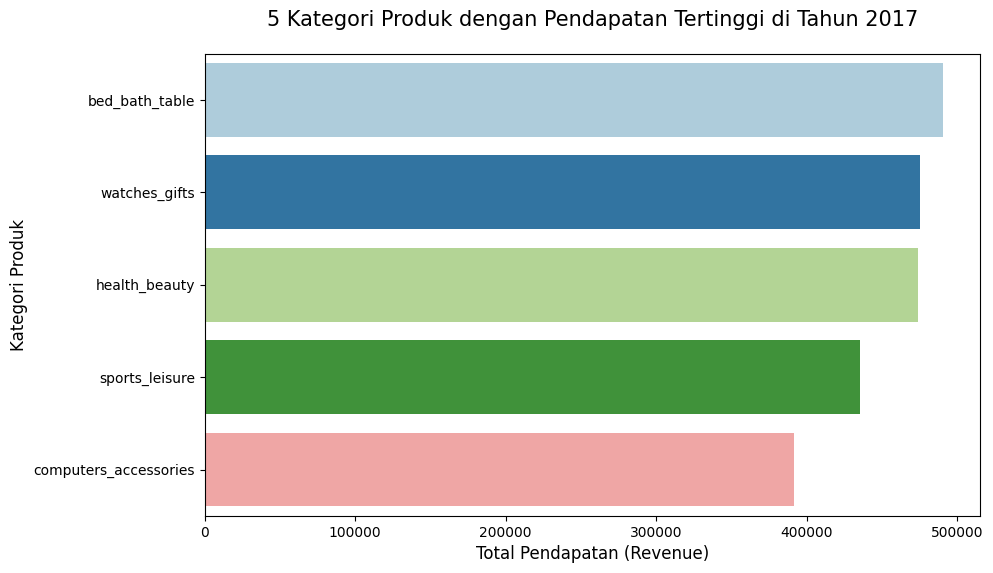

In [77]:
# 1. Menyiapkan data: Filter tahun 2017 dan ambil Top 5 kategori berdasarkan revenue
df_2017 = all_df[all_df['order_purchase_timestamp'].dt.year == 2017]
top_categories_2017 = df_2017.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).reset_index().head(5)

# 2. Membuat visualisasi bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x="price",
    y="product_category_name_english",
    data=top_categories_2017,
    palette="Paired",
    hue="product_category_name_english",
    legend=False
)

# 3. Menambahkan label dan judul untuk integritas data
plt.title("5 Kategori Produk dengan Pendapatan Tertinggi di Tahun 2017", fontsize=15, pad=20)
plt.xlabel("Total Pendapatan (Revenue)", fontsize=12)
plt.ylabel("Kategori Produk", fontsize=12)
plt.show()

### Pertanyaan 2:

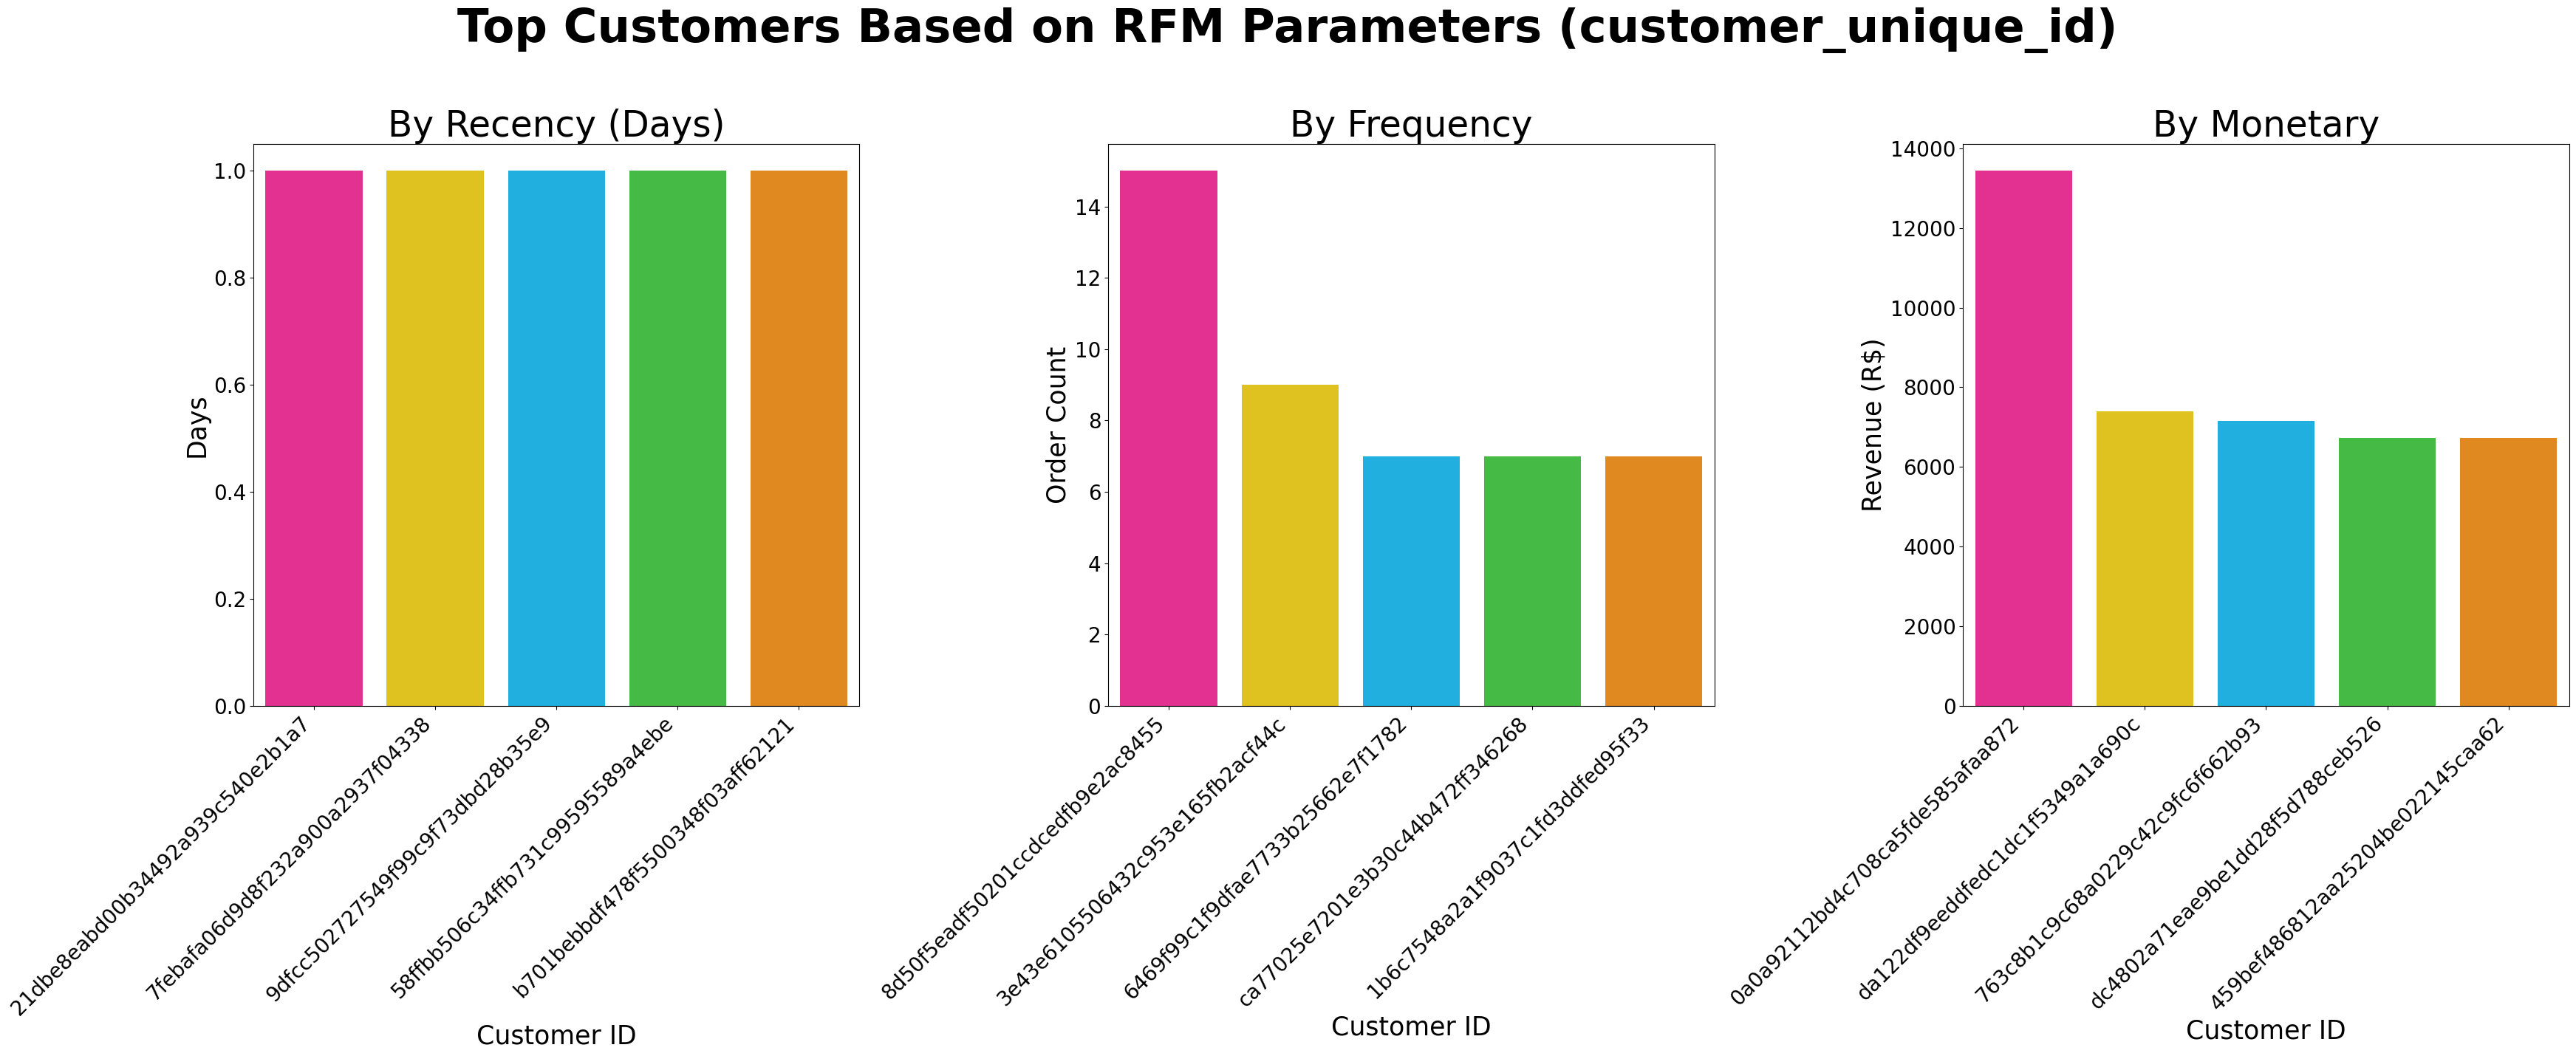

In [78]:
import datetime as dt

max_purchase_timestamp = all_df['order_purchase_timestamp'].max()
current_date = max_purchase_timestamp + dt.timedelta(days=1)

# Menghitung metrik RFM
# Menghitung metrik RFM
rfm_df = all_df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda date: (current_date - date.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

rfm_df = rfm_df.rename(columns={'customer_unique_id': 'customer_id'})

top_5_recency = rfm_df.sort_values(by="recency", ascending=True).head(5)
top_5_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5)
top_5_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5)

# 2. Setup Plot
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(35, 15))

vibrant_colors = ["#FF1493", "#FFD700", "#00BFFF", "#32CD32", "#FF8C00"]

# Visualisasi By Recency
sns.barplot(
    y="recency",
    x="customer_id",
    data=top_5_recency,
    palette=vibrant_colors,
    hue="customer_id",
    legend=False,
    ax=ax[0]
)
ax[0].set_ylabel("Days", fontsize=25)
ax[0].set_xlabel("Customer ID", fontsize=25)
ax[0].set_title("By Recency (Days)", loc="center", fontsize=35)
ax[0].set_xticks(range(len(top_5_recency)))
ax[0].set_xticklabels([id for id in top_5_recency["customer_id"]], rotation=45, ha='right', fontsize=20)
ax[0].tick_params(axis='y', labelsize=20)

# Visualisasi By Frequency
sns.barplot(
    y="frequency",
    x="customer_id",
    data=top_5_frequency,
    palette=vibrant_colors,
    hue="customer_id",
    legend=False,
    ax=ax[1]
)
ax[1].set_ylabel("Order Count", fontsize=25)
ax[1].set_xlabel("Customer ID", fontsize=25)
ax[1].set_title("By Frequency", loc="center", fontsize=35)
ax[1].set_xticks(range(len(top_5_frequency)))
ax[1].set_xticklabels([id for id in top_5_frequency["customer_id"]], rotation=45, ha='right', fontsize=20)
ax[1].tick_params(axis='y', labelsize=20)

# Visualisasi By Monetary
sns.barplot(
    y="monetary",
    x="customer_id",
    data=top_5_monetary,
    palette=vibrant_colors,
    hue="customer_id",
    legend=False,
    ax=ax[2]
)
ax[2].set_ylabel("Revenue (R$)", fontsize=25)
ax[2].set_xlabel("Customer ID", fontsize=25)
ax[2].set_title("By Monetary", loc="center", fontsize=35)
ax[2].set_xticks(range(len(top_5_monetary)))
ax[2].set_xticklabels([id for id in top_5_monetary["customer_id"]], rotation=45, ha='right', fontsize=20)
ax[2].tick_params(axis='y', labelsize=20)

plt.suptitle("Top Customers Based on RFM Parameters (customer_unique_id)", fontsize=45, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:** (Opsional)
- Berdasarkan visualisasi, kategori bed_bath_table merupakan penyumbang pendapatan tertinggi sepanjang tahun 2017, disusul ketat oleh kategori watches_gifts dan health_beauty. Hal ini menunjukkan bahwa strategi pemasaran dan ketersediaan stok pada sektor kebutuhan rumah tangga serta gaya hidup sangat efektif dalam menarik daya beli pelanggan. Untuk tahun berikutnya, kategori-kategori ini harus tetap menjadi fokus utama promosi guna mempertahankan stabilitas revenue perusahaan.

- Analisis RFM berhasil memetakan segmen pelanggan "VIP" yang sangat krusial bagi keberlangsungan bisnis. Dari sisi Frequency dan Monetary, terdapat segelintir pelanggan sangat loyal dengan frekuensi belanja rutin dan nilai transaksi masif (mencapai lebih dari R$ 13.000). Sementara itu, grafik Recency kini menyoroti pelanggan-pelanggan potensial yang baru saja aktif bertransaksi (dalam hitungan hari). Pelanggan yang memiliki kombinasi skor tinggi pada ketiga metrik inilah yang harus menjadi prioritas utama tim pemasaran untuk segera ditawarkan program loyalty eksklusif sebelum mereka berpindah ke kompetitor.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk dengan pendapatan tertinggi pada tahun 2017 adalah bed_bath_table, watches_gifts, dan health_beauty. Hal ini membuktikan adanya permintaan pasar yang kuat dan stabil pada sektor perlengkapan rumah tangga serta kebutuhan gaya hidup sepanjang tahun tersebut.
- **Conclusion pertanyaan 2:** Analisis RFM menunjukkan adanya segmen pelanggan dengan kontribusi nilai transaksi (Monetary) yang sangat signifikan. Di sisi lain, analisis musiman pada kategori unggulan mendeteksi adanya lonjakan pesanan yang drastis pada bulan November, yang mengindikasikan sensitivitas pelanggan terhadap momen promosi besar seperti Black Friday.

**Rekomendasi Action Item:**
- Tim operasional disarankan untuk meningkatkan ketersediaan stok produk pada kategori top-performing setidaknya dua bulan sebelum bulan November untuk mengantisipasi lonjakan musiman yang berulang setiap tahunnya.
- Meluncurkan program loyalitas eksklusif untuk menjaga retensi pelanggan di segmen High Monetary, serta melakukan kampanye pemasaran ulang (re-engagement) melalui promo khusus bagi pelanggan dengan nilai Recency tinggi agar mereka kembali bertransaksi sebelum benar-benar berpindah ke kompetitor.